#E-Visor — Predicción por Clúster

**Estrategia:** Un modelo especializado por clúster que predice todos sus bloques simultáneamente.
- **C0** (Académico estándar, 6 bloques): XGBoost pooled con features cíclicas + ventanas
- **C1** (Alto consumo eficiente, 2 bloques): XGBoost pooled
- **C2** (Aulas ineficientes, 6 bloques): LightGBM con regresión cuantil (p10/p50/p90) por alta variabilidad
- **C3** (Operación constante, 1 bloque): XGBoost simple

**Datos:** Feb 10 – Mar 28 2026 (1128h/bloque). Corte antes del apagón de 198h del 29 de marzo.

**Validación:** Walk-forward backtesting con re-entrenamiento cada 24h sobre las últimas 2 semanas (336h).

## 1. Instalación e importaciones

In [ ]:
!pip install xgboost==2.0.3 lightgbm==4.3.0 --quiet

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import joblib

## 2. Carga de datos y configuración de clústeres

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ── Parámetros globales ────────────────────────────────────────────────────
FILE_PATH   = '/content/drive/MyDrive/datos_limpios_prediccion/datos_limpios_09042026.csv'
CUTOFF_DATE = pd.Timestamp('2026-03-29')   # Inicio apagón de 198h
TEST_HOURS  = 336                           # 2 semanas de test
HORIZON     = 168                           # Horizonte de predicción: 1 semana
STEP        = 24                            # Re-entrenamiento cada 24h (walk-forward)

# ── Asignación bloque → clúster ───────────────────────────────────────────
CLUSTER_MAP = {
    'SmartMeter_SM_B10_ARQ': 0, 'SmartMeter_SM_B4_PRIM': 0,
    'SmartMeter_SM_B5_BACH': 0, 'SmartMeter_SM_B7_TAC':  0,
    'SmartMeter_SM_B8_LABS': 0, 'SmartMeter_SM_B9_SFA2': 0,
    'SmartMeter_SM_B12_DERE': 2, 'SmartMeter_SM_B17_POLI': 2,
    'SmartMeter_SM_B3_RECT':  2, 'SmartMeter_SM_B8_AA':   2,
    'SmartMeter_SM_B8_CPA':   2, 'SmartMeter_SM_ECOVILLA': 2,
    'SmartMeter_SM_B18_PARQ': 1, 'SmartMeter_SM_B9_SFA1': 1,
    'SmartMeter_SM_B7_CTIC':  3,
}

CLUSTER_NAMES = {
    0: 'Académico estándar',
    1: 'Alto consumo eficiente',
    2: 'Aulas ineficientes',
    3: 'Operación constante',
}

# ── Festivos Colombia en el período de datos ───────────────────────────────
FESTIVOS = pd.to_datetime([
    '2026-03-23',  # San José
    #agregar más cuando sea necesario
])

print(f'   Clústeres: {len(set(CLUSTER_MAP.values()))} | Bloques: {len(CLUSTER_MAP)}')
print(f'   Test: {TEST_HOURS}h | Horizonte: {HORIZON}h | Step: {STEP}h')

   Clústeres: 4 | Bloques: 15
   Test: 336h | Horizonte: 168h | Step: 24h


In [8]:
# ── Carga y limpieza ──────────────────────────────────────────────────────
df_raw = pd.read_csv(FILE_PATH)
df_raw['time_index_colombia'] = pd.to_datetime(df_raw['time_index_colombia']) #Tipo fecha

# Cortar antes del apagón
df_raw = df_raw[df_raw['time_index_colombia'] < CUTOFF_DATE].copy()
df_raw['cluster'] = df_raw['entity_id'].map(CLUSTER_MAP)

print(f'Shape tras corte: {df_raw.shape}')
print(f'Rango: {df_raw["time_index_colombia"].min().date()} → {df_raw["time_index_colombia"].max().date()}')
print(f'Horas por bloque: {df_raw.groupby("entity_id").size().iloc[0]}')
print()

# Resumen de variabilidad por clúster
summary = []
for c in sorted(df_raw['cluster'].unique()):
    sub = df_raw[df_raw['cluster'] == c]['activepower']
    summary.append({
        'Clúster': f'C{c} – {CLUSTER_NAMES[c]}',
        'Bloques': df_raw[df_raw['cluster']==c]['entity_id'].nunique(),
        'Mean (W)': f'{sub.mean():.0f}', #potencia activa promedio
        'CV (%)': f'{sub.std()/sub.mean()*100:.1f}', #coeficiente de variación
        'Min (W)': f'{sub.min():.0f}', #min potencia activa
        'Max (W)': f'{sub.max():.0f}', #max potencia activa
    })
display(pd.DataFrame(summary).set_index('Clúster'))

Shape tras corte: (16920, 14)
Rango: 2026-02-10 → 2026-03-28
Horas por bloque: 1128



,Bloques,Mean (W),CV (%),Min (W),Max (W)
Clúster,,,,,
C0 – Académico estándar,6,20225,71.1,1044,82957
C1 – Alto consumo eficiente,2,37729,49.2,11034,83829
C2 – Aulas ineficientes,6,4033,114.0,38,25438
C3 – Operación constante,1,36408,10.2,24630,47372


## 3. Feature Engineering (compartido por todos los clústeres)

In [9]:
def build_features(df_bloque: pd.DataFrame, festivos=FESTIVOS) -> pd.DataFrame:
    """
    Construye features para un único bloque ya indexado por tiempo (frecuencia horaria).
    Todas las operaciones usan shift() > 0 → sin data leakage.

    Args:
        df_bloque: DataFrame con columna 'y' e índice DatetimeIndex horario.
    Returns:
        DataFrame con todas las features + columna 'y' (target).
    """
    df = df_bloque.copy()

    # 1. Variables cíclicas (preservan circularidad de hora/día/mes)
    df['hora_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dia_sin']  = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dia_cos']  = np.cos(2 * np.pi * df.index.dayofweek / 7)
    df['mes_sin']  = np.sin(2 * np.pi * df.index.month / 12)
    df['mes_cos']  = np.cos(2 * np.pi * df.index.month / 12)

    # 2. Variables contextuales universitarias
    df['es_fin_de_semana'] = (df.index.dayofweek >= 5).astype(int)
    df['es_festivo']       = df.index.normalize().isin(festivos).astype(int)
    df['dia_no_laboral']   = df[['es_fin_de_semana', 'es_festivo']].max(axis=1)
    # Hora pico académica: 7am–8pm en días hábiles
    df['es_hora_pico'] = (
        (df.index.hour >= 7) & (df.index.hour <= 20) &
        (df.index.dayofweek < 5) & (df['dia_no_laboral'] == 0)
    ).astype(int)

    # 3. Lags selectivos (solo pasado garantizado)
    for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
        df[f'lag_{lag}h'] = df['y'].shift(lag)

    # 4. Ventanas móviles (shift(1) antes del rolling → sin leakage)
    y_shifted = df['y'].shift(1)
    df['media_24h']  = y_shifted.rolling(window=24,  min_periods=12).mean()
    df['std_24h']    = y_shifted.rolling(window=24,  min_periods=12).std()
    df['min_24h']    = y_shifted.rolling(window=24,  min_periods=12).min()
    df['max_24h']    = y_shifted.rolling(window=24,  min_periods=12).max()
    df['media_168h'] = y_shifted.rolling(window=168, min_periods=84).mean()
    df['std_168h']   = y_shifted.rolling(window=168, min_periods=84).std()

    return df


def preparar_cluster(df_raw: pd.DataFrame, cluster_id: int) -> dict:
    """
    Prepara el dataset para un clúster completo.
    Aplica features a cada bloque y concatena.

    Returns:
        dict con 'df_all' (features de todo el clúster), 'bloques' (lista),
        'X_train', 'y_train', 'X_test', 'y_test', 'test_index'.
    """
    bloques = sorted(df_raw[df_raw['cluster'] == cluster_id]['entity_id'].unique())
    dfs = []

    for bloque in bloques:
        sub = (
            df_raw[df_raw['entity_id'] == bloque]
            .set_index('time_index_colombia')
            .sort_index()[['activepower']]
            .rename(columns={'activepower': 'y'})
            .asfreq('h')
        )
        # # Interpolar huecos pequeños si los hubiera
        # if sub['y'].isna().sum() > 0:
        #     sub['y'] = sub['y'].interpolate(method='time', limit=3)
        #     sub = sub.dropna()

        feat = build_features(sub)
        feat = feat.dropna()  # Eliminar filas con NaN de lags/rolling
        feat['entity_id'] = bloque
        feat['cluster']   = cluster_id
        dfs.append(feat)

    df_all = pd.concat(dfs).sort_index()

    # Split temporal: test = últimas TEST_HOURS por bloque
    # Tomamos el corte como el timestamp -TEST_HOURS del último bloque
    timestamps = sorted(df_all.index.unique())
    corte = timestamps[-TEST_HOURS]

    FEATURE_COLS = [c for c in df_all.columns if c not in ['y', 'entity_id', 'cluster']]

    # Encoding de entity_id como categórica ordinal
    bloque_enc = {b: i for i, b in enumerate(bloques)}
    df_all['bloque_enc'] = df_all['entity_id'].map(bloque_enc)
    FEATURE_COLS = FEATURE_COLS + ['bloque_enc']

    train = df_all[df_all.index <  corte]
    test  = df_all[df_all.index >= corte]

    return {
        'df_all':       df_all,
        'bloques':      bloques,
        'bloque_enc':   bloque_enc,
        'feature_cols': FEATURE_COLS,
        'X_train': train[FEATURE_COLS],
        'y_train': train['y'],
        'X_test':  test[FEATURE_COLS],
        'y_test':  test['y'],
        'test_df': test,
        'corte':   corte,
    }

print('Funciones de feature engineering definidas')

Funciones de feature engineering definidas


## 4. Funciones de evaluación y walk-forward

In [10]:
def safe_mape(y_true, y_pred, epsilon=50):
    """
    MAPE con umbral mínimo en y_true para evitar explosión cuando el valor real ≈ 0.
    Útil especialmente para C2 (Aulas ineficientes) con valores muy bajos en horas nocturnas.
    epsilon en Watts: si y_true < epsilon, se excluye del cálculo.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true >= epsilon
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def evaluar_por_bloque(y_true_series, y_pred_series, entity_series, cluster_name):
    """
    Calcula métricas por bloque y el agregado del clúster.
    """
    rows = []
    for bloque in sorted(entity_series.unique()):
        mask = entity_series == bloque
        yt = y_true_series[mask]
        yp = y_pred_series[mask]
        rows.append({
            'Bloque':   bloque.replace('SmartMeter_SM_', ''),
            'MAE (W)':  mean_absolute_error(yt, yp),
            'RMSE (W)': np.sqrt(mean_squared_error(yt, yp)),
            'MAPE (%)': safe_mape(yt, yp) * 100,
            'n_horas':  len(yt),
        })

    df_metrics = pd.DataFrame(rows).set_index('Bloque')

    # Fila de totales
    df_metrics.loc[f'── TOTAL {cluster_name} ──'] = {
        'MAE (W)':  mean_absolute_error(y_true_series, y_pred_series),
        'RMSE (W)': np.sqrt(mean_squared_error(y_true_series, y_pred_series)),
        'MAPE (%)': safe_mape(y_true_series, y_pred_series) * 100,
        'n_horas':  len(y_true_series),
    }

    return df_metrics.round(2)


def plot_predicciones(y_true_series, y_pred_series, entity_series, cluster_name, titulo_extra=''):
    """
    Gráfico Real vs Predicho para cada bloque del clúster.
    """
    bloques = sorted(entity_series.unique())
    n = len(bloques)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, bloque in zip(axes, bloques):
        mask = entity_series == bloque
        yt = y_true_series[mask]
        yp = y_pred_series[mask]
        mape = safe_mape(yt, yp) * 100
        mae  = mean_absolute_error(yt, yp)

        ax.plot(yt.index, yt.values, label='Real',       color='steelblue',  lw=1.5)
        ax.plot(yp.index, yp.values, label='Predicción', color='darkorange', lw=1.2, ls='--')
        ax.set_title(f'{bloque.replace("SmartMeter_SM_","")} — MAPE: {mape:.1f}% | MAE: {mae:.0f} W',
                     fontsize=11)
        ax.set_ylabel('Potencia (W)')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    fig.suptitle(f'Clúster {cluster_name} {titulo_extra} — Real vs Predicción (Test)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def walk_forward_predict(modelo, df_cluster_all, data_info, paso=24):
    """
    Walk-forward: re-entrena el modelo cada `paso` horas usando todos los datos
    disponibles hasta ese momento. Predice las siguientes `paso` horas.

    NOTA: Para clústeres con pocos bloques (C1, C3) esto puede ser lento.
          Para un entrenamiento rápido, usa predict_directo() en su lugar.
    """
    feature_cols = data_info['feature_cols']
    timestamps   = sorted(df_cluster_all.index.unique())
    corte        = data_info['corte']
    test_df      = data_info['test_df']
    test_ts      = sorted(test_df.index.unique())

    all_preds = []

    for i in range(0, len(test_ts), paso):
        ventana_test = test_ts[i:i+paso]
        if not ventana_test:
            break

        # Train: todos los datos hasta antes de esta ventana
        cutoff_wf   = ventana_test[0]
        train_slice = df_cluster_all[df_cluster_all.index < cutoff_wf]
        modelo.fit(train_slice[feature_cols], train_slice['y'])

        # Predecir ventana
        test_slice = test_df[test_df.index.isin(ventana_test)]
        preds = modelo.predict(test_slice[feature_cols])
        preds = pd.Series(preds, index=test_slice.index, name='y_pred')
        all_preds.append(test_slice[['y', 'entity_id']].assign(y_pred=preds))

    return pd.concat(all_preds).sort_index()


def predict_directo(modelo, data_info):
    """
    Predicción directa (sin walk-forward): entrena en train, predice todo el test.
    Más rápido, ligeramente menos preciso para horizontes largos.
    """
    modelo.fit(data_info['X_train'], data_info['y_train'])
    preds = modelo.predict(data_info['X_test'])
    result = data_info['test_df'][['y', 'entity_id']].copy()
    result['y_pred'] = preds
    return result


print('Funciones de evaluación y predicción definidas')

Funciones de evaluación y predicción definidas


## 5. C3 — Operación constante (B7_CTIC)
CV ≈ 9% → el más fácil. XGBoost simple, sin walk-forward necesario.

In [11]:
print('=== Preparando C3 — Operación constante ===')
c3_data = preparar_cluster(df_raw, cluster_id=3)
print(f'Train: {len(c3_data["X_train"])} filas | Test: {len(c3_data["X_test"])} filas')
print(f'Features: {len(c3_data["feature_cols"])}')
print(f'Corte train/test: {c3_data["corte"]}')

=== Preparando C3 — Operación constante ===
Train: 624 filas | Test: 336 filas
Features: 26
Corte train/test: 2026-03-15 00:00:00


In [12]:
modelo_c3 = XGBRegressor(
    n_estimators    = 800,
    learning_rate   = 0.02,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
)

result_c3 = predict_directo(modelo_c3, c3_data)

metrics_c3 = evaluar_por_bloque(
    result_c3['y'], result_c3['y_pred'], result_c3['entity_id'],
    CLUSTER_NAMES[3]
)
print('\nMétricas C3:')
display(metrics_c3)


Métricas C3:


,MAE (W),RMSE (W),MAPE (%),n_horas
Bloque,,,,
B7_CTIC,1576.6,2672.66,5.11,336
── TOTAL Operación constante ──,1576.6,2672.66,5.11,336


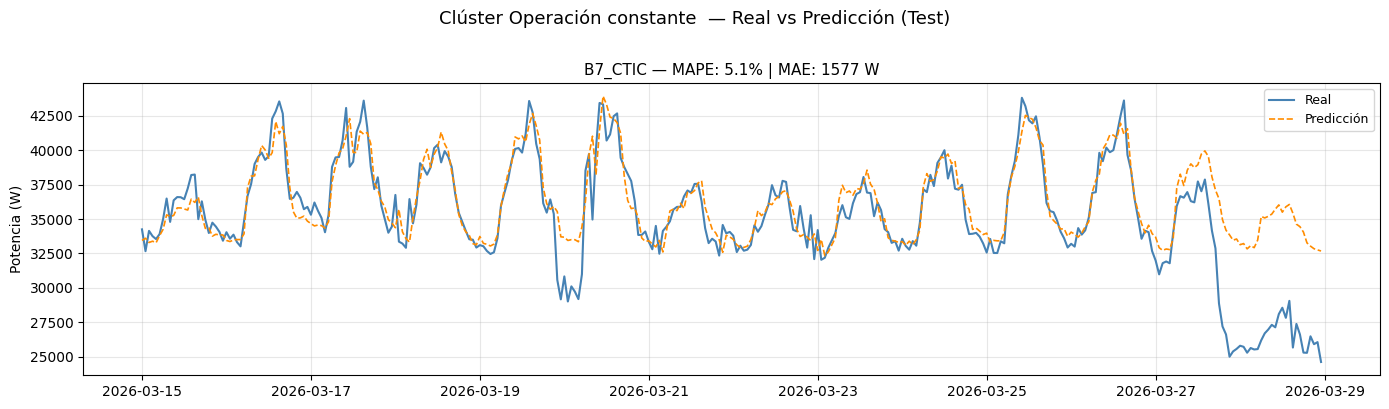

In [13]:
plot_predicciones(
    result_c3['y'], result_c3['y_pred'], result_c3['entity_id'],
    CLUSTER_NAMES[3]
)

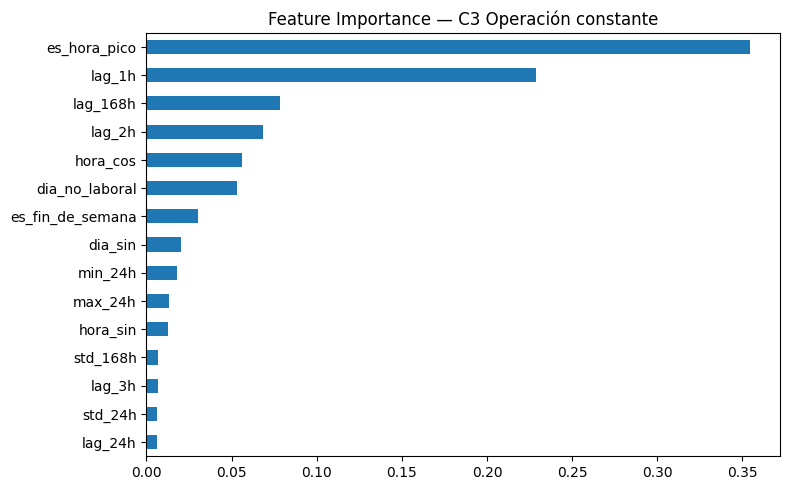

In [14]:
# Feature importance C3
fi_c3 = pd.Series(modelo_c3.feature_importances_, index=c3_data['feature_cols']).sort_values(ascending=True)
fi_c3.tail(15).plot(kind='barh', figsize=(8, 5), title='Feature Importance — C3 Operación constante')
plt.tight_layout()
plt.show()

## 6. C1 — Alto consumo eficiente (B18_PARQ, B9_SFA1)
CV ≈ 45–49% → XGBoost con walk-forward. Solo 2 bloques → la estrategia pooled
aporta diversidad de patrones. Se añade `bloque_enc` para que el modelo diferencie entre bloques.

In [15]:
print('=== Preparando C1 — Alto consumo eficiente ===')
c1_data = preparar_cluster(df_raw, cluster_id=1)
print(f'Bloques: {c1_data["bloques"]}')
print(f'Train: {len(c1_data["X_train"])} filas | Test: {len(c1_data["X_test"])} filas')

=== Preparando C1 — Alto consumo eficiente ===
Bloques: ['SmartMeter_SM_B18_PARQ', 'SmartMeter_SM_B9_SFA1']
Train: 1248 filas | Test: 672 filas


In [16]:
modelo_c1 = XGBRegressor(
    n_estimators    = 600,
    learning_rate   = 0.04,
    max_depth       = 5,
    subsample       = 0.8,
    colsample_bytree= 0.75,
    reg_alpha       = 0.5,
    reg_lambda      = 2.0,
    random_state    = 42,
    n_jobs          = -1,
)

# Walk-forward para mayor precisión en horizonte de 1 semana
result_c1 = walk_forward_predict(
    modelo_c1, c1_data['df_all'], c1_data, paso=STEP
)

metrics_c1 = evaluar_por_bloque(
    result_c1['y'], result_c1['y_pred'], result_c1['entity_id'],
    CLUSTER_NAMES[1]
)
print('\nMétricas C1:')
display(metrics_c1)


Métricas C1:


,MAE (W),RMSE (W),MAPE (%),n_horas
Bloque,,,,
B18_PARQ,4071.08,5406.26,15.59,336
B9_SFA1,2832.21,4001.47,8.83,336
── TOTAL Alto consumo eficiente ──,3451.64,4756.02,12.21,672


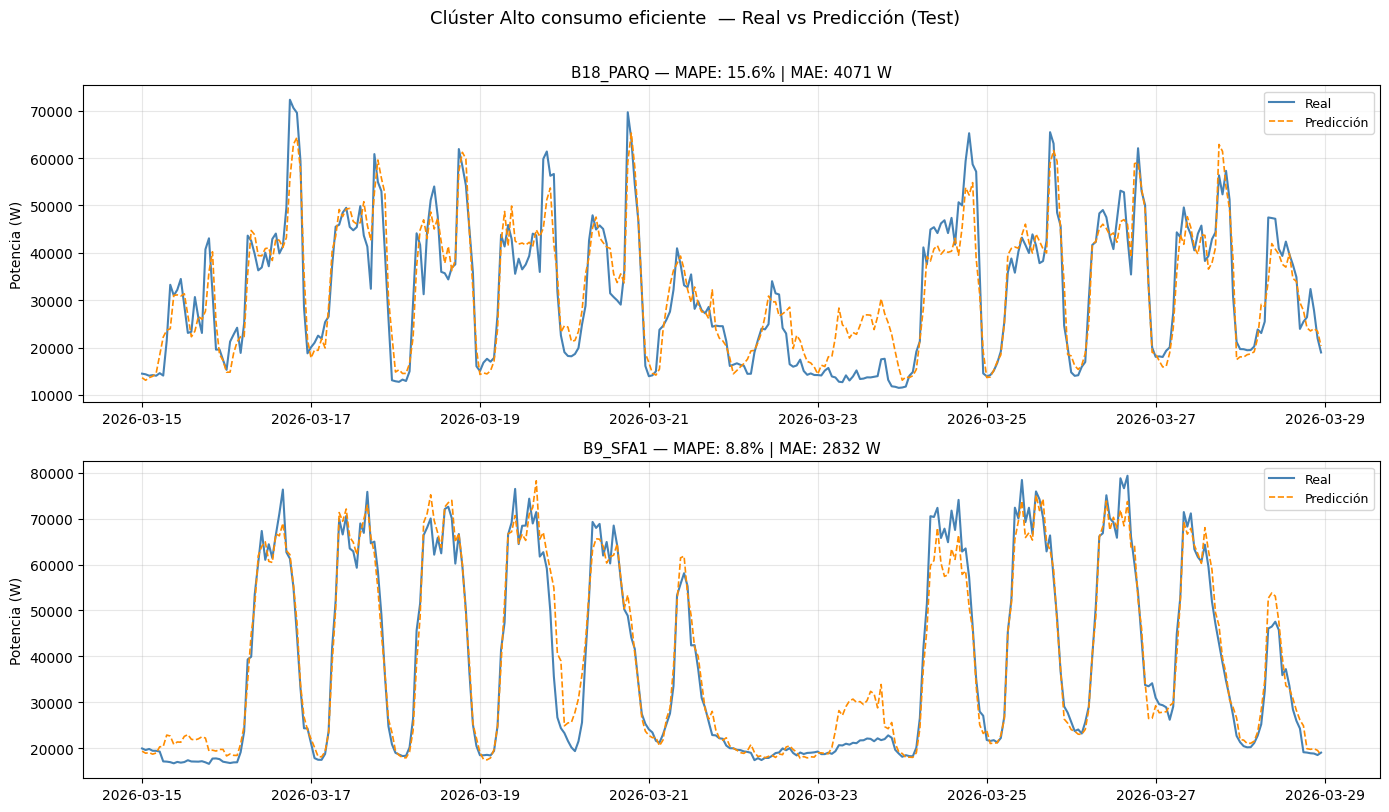

In [17]:
plot_predicciones(
    result_c1['y'], result_c1['y_pred'], result_c1['entity_id'],
    CLUSTER_NAMES[1]
)

## 7. C0 — Académico estándar (6 bloques)
CV ≈ 53–70%. Patrón claro de actividad académica (picos entre semana, caída fines de semana).
XGBoost pooled con walk-forward. El `bloque_enc` permite al modelo personalizar por edificio.

In [18]:
print('=== Preparando C0 — Académico estándar ===')
c0_data = preparar_cluster(df_raw, cluster_id=0)
print(f'Bloques: {c0_data["bloques"]}')
print(f'Train: {len(c0_data["X_train"])} filas | Test: {len(c0_data["X_test"])} filas')

=== Preparando C0 — Académico estándar ===
Bloques: ['SmartMeter_SM_B10_ARQ', 'SmartMeter_SM_B4_PRIM', 'SmartMeter_SM_B5_BACH', 'SmartMeter_SM_B7_TAC', 'SmartMeter_SM_B8_LABS', 'SmartMeter_SM_B9_SFA2']
Train: 3744 filas | Test: 2016 filas


In [19]:
modelo_c0 = XGBRegressor(
    n_estimators    = 700,
    learning_rate   = 0.04,
    max_depth       = 6,
    subsample       = 0.75,
    colsample_bytree= 0.7,
    reg_alpha       = 1.0,
    reg_lambda      = 2.0,
    min_child_weight= 5,
    random_state    = 42,
    n_jobs          = -1,
)

result_c0 = walk_forward_predict(
    modelo_c0, c0_data['df_all'], c0_data, paso=STEP
)

metrics_c0 = evaluar_por_bloque(
    result_c0['y'], result_c0['y_pred'], result_c0['entity_id'],
    CLUSTER_NAMES[0]
)
print('\nMétricas C0:')
display(metrics_c0)


Métricas C0:


,MAE (W),RMSE (W),MAPE (%),n_horas
Bloque,,,,
B10_ARQ,2055.09,3392.47,24.49,336
B4_PRIM,2160.57,3501.50,11.85,336
B5_BACH,2747.31,4408.46,11.72,336
B7_TAC,1586.03,2364.35,13.33,336
B8_LABS,1354.12,1813.55,9.52,336
B9_SFA2,3120.23,4809.07,11.73,336
── TOTAL Académico estándar ──,2170.56,3540.48,13.77,2016


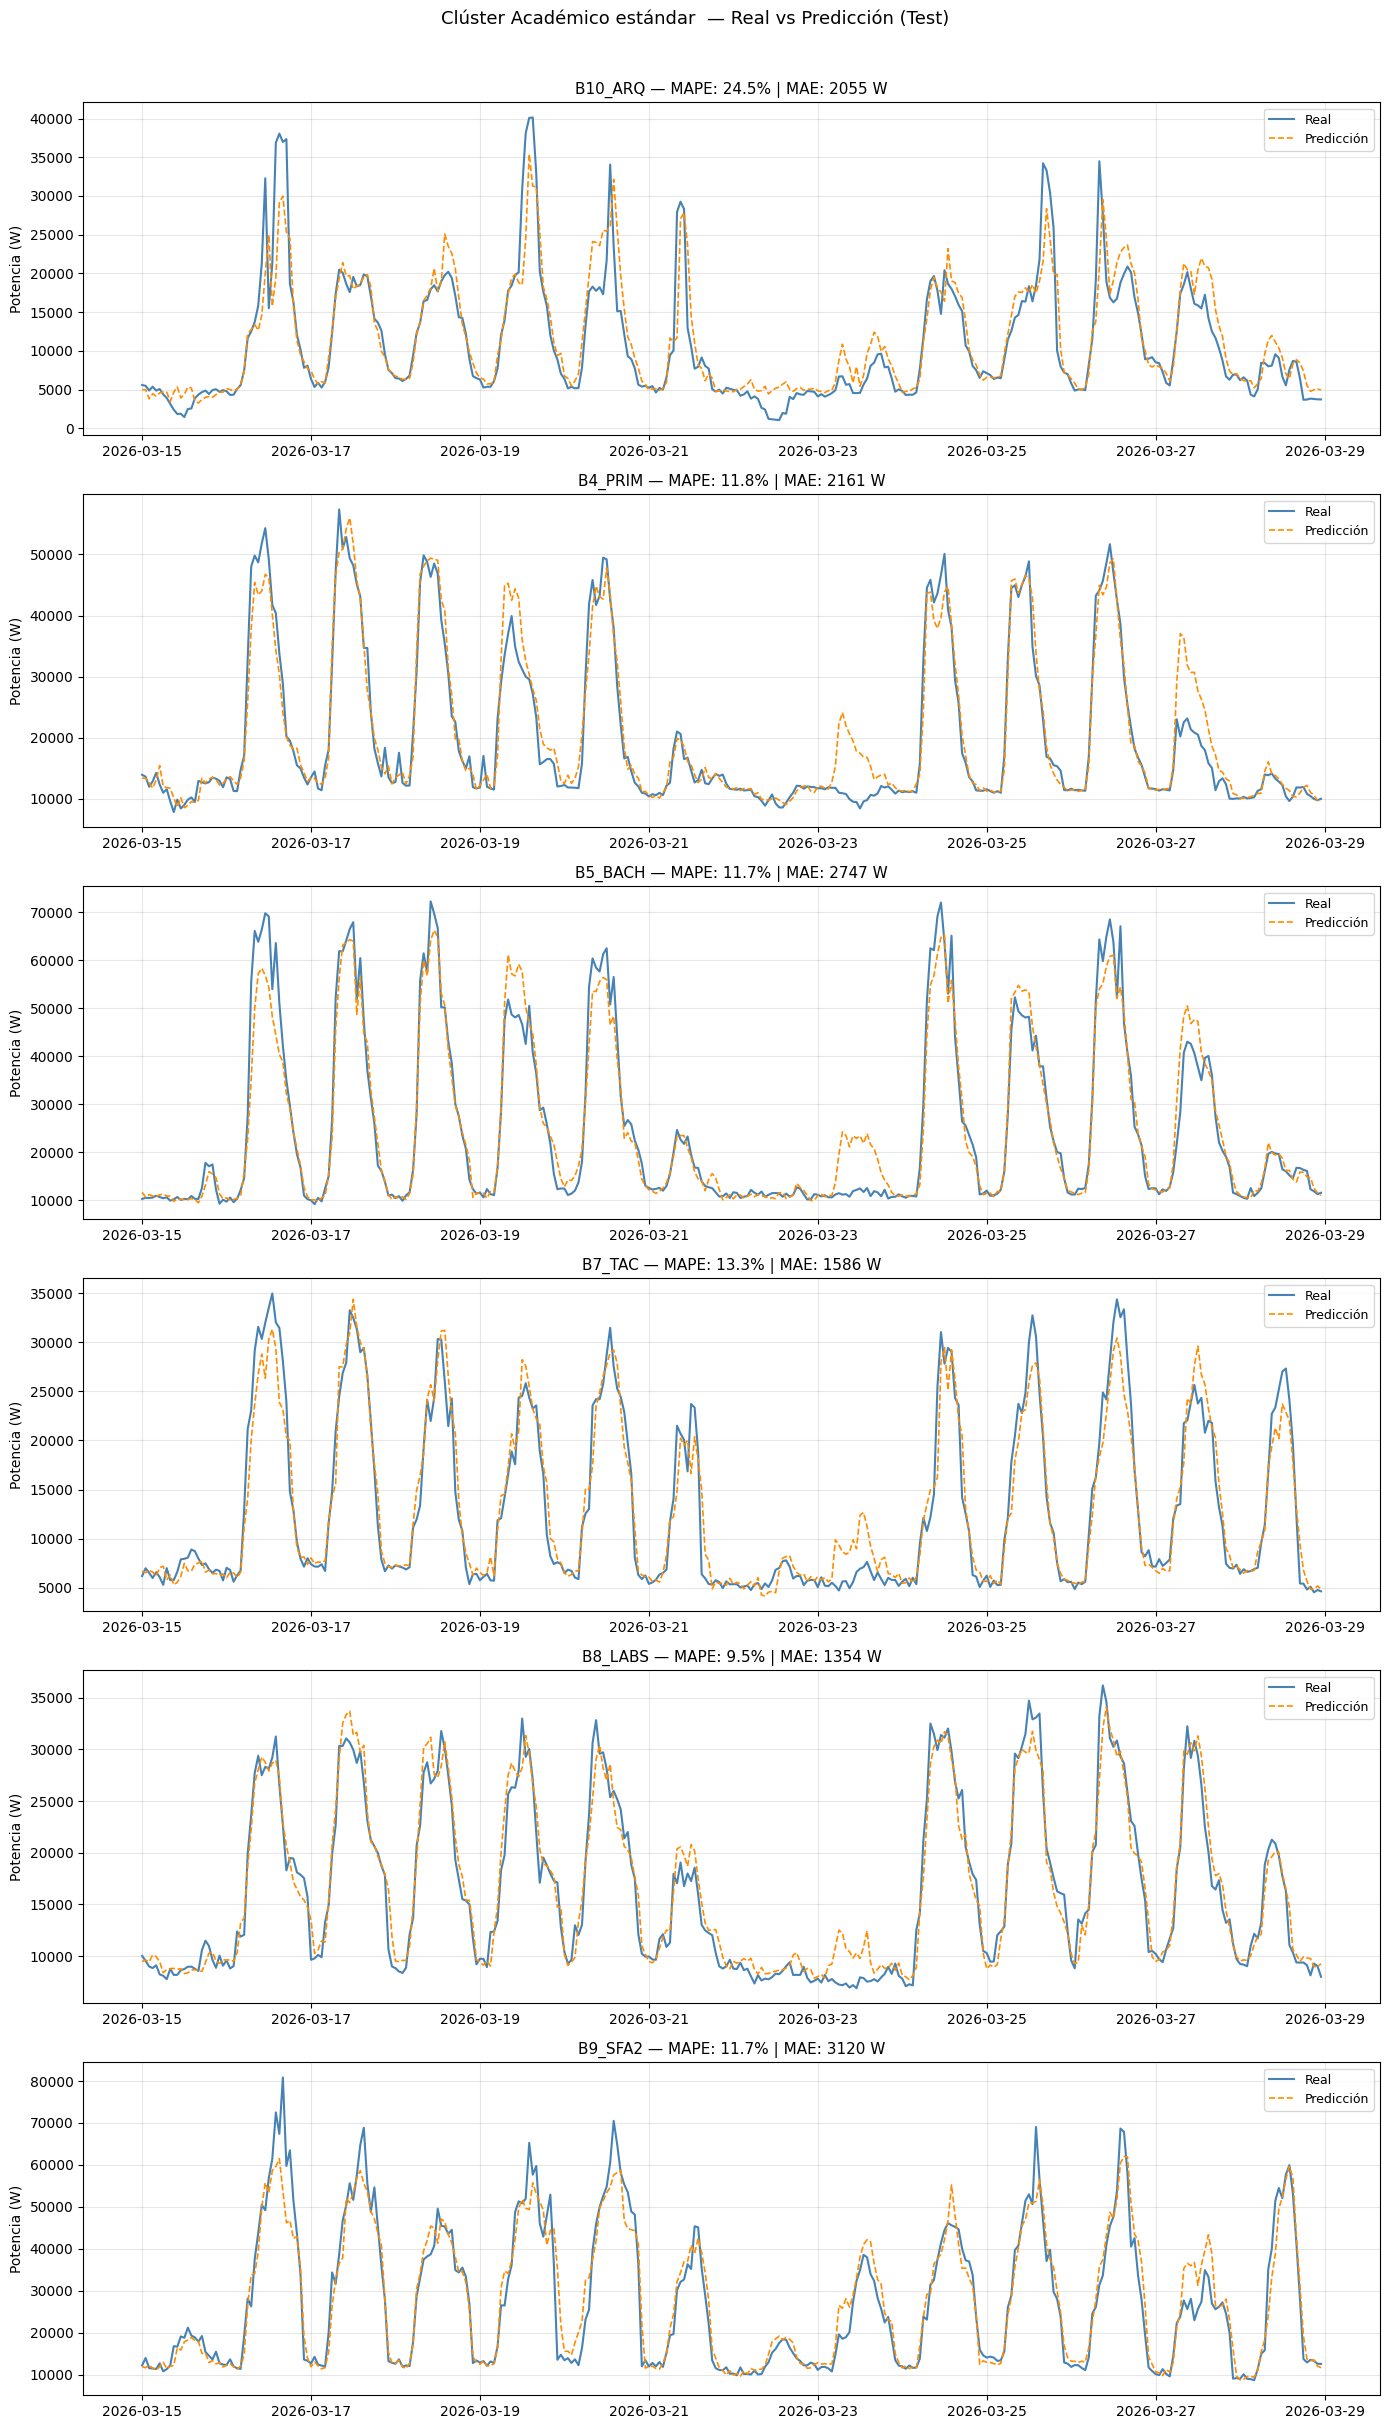

In [20]:
plot_predicciones(
    result_c0['y'], result_c0['y_pred'], result_c0['entity_id'],
    CLUSTER_NAMES[0]
)

## 8. C2 — Aulas ineficientes (6 bloques) — Regresión cuantil

CV ≈ 46–121%. Los bloques B8_AA y ECOVILLA son extremadamente volátiles.

**Estrategia:** LightGBM con `objective='quantile'` para los cuantiles p10, p50, p90.
- El **p50** es la predicción puntual principal.
- El **intervalo [p10, p90]** captura la incertidumbre real → honesto ante la alta variabilidad.
- El MAPE se reporta con `epsilon=50W` para excluir horas nocturnas donde el consumo ≈ 0.

In [21]:
print('=== Preparando C2 — Aulas ineficientes ===')
c2_data = preparar_cluster(df_raw, cluster_id=2)
print(f'Bloques: {c2_data["bloques"]}')
print(f'Train: {len(c2_data["X_train"])} filas | Test: {len(c2_data["X_test"])} filas')

# Variabilidad por bloque de C2 para justificar cuantiles
print('\nCV por bloque de C2:')
for b in c2_data['bloques']:
    sub = df_raw[df_raw['entity_id'] == b]['activepower']
    print(f'  {b.replace("SmartMeter_SM_","")}: CV={sub.std()/sub.mean()*100:.1f}%')

=== Preparando C2 — Aulas ineficientes ===
Bloques: ['SmartMeter_SM_B12_DERE', 'SmartMeter_SM_B17_POLI', 'SmartMeter_SM_B3_RECT', 'SmartMeter_SM_B8_AA', 'SmartMeter_SM_B8_CPA', 'SmartMeter_SM_ECOVILLA']
Train: 3744 filas | Test: 2016 filas

CV por bloque de C2:
  B12_DERE: CV=64.3%
  B17_POLI: CV=52.9%
  B3_RECT: CV=75.5%
  B8_AA: CV=122.0%
  B8_CPA: CV=71.8%
  ECOVILLA: CV=121.3%


In [22]:
# ── Parámetros base de LightGBM ────────────────────────────────────────────
LGBM_BASE = dict(
    n_estimators    = 800,
    learning_rate   = 0.03,
    max_depth       = 7,
    num_leaves      = 63,
    subsample       = 0.7,
    colsample_bytree= 0.7,
    reg_alpha       = 2.0,
    reg_lambda      = 3.0,
    min_child_samples = 20,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1,
)

# Entrena los 3 cuantiles
modelos_c2 = {}
for q in [0.1, 0.5, 0.9]:
    print(f'  Entrenando cuantil p{int(q*100)}...')
    m = LGBMRegressor(objective='quantile', alpha=q, **LGBM_BASE)
    m.fit(c2_data['X_train'], c2_data['y_train'])
    modelos_c2[q] = m

print('✅ Modelos cuantil entrenados')

  Entrenando cuantil p10...
  Entrenando cuantil p50...
  Entrenando cuantil p90...
✅ Modelos cuantil entrenados


In [23]:
# Predicciones para los 3 cuantiles
result_c2 = c2_data['test_df'][['y', 'entity_id']].copy()
result_c2['y_pred_p10'] = modelos_c2[0.1].predict(c2_data['X_test'])
result_c2['y_pred_p50'] = modelos_c2[0.5].predict(c2_data['X_test'])
result_c2['y_pred_p90'] = modelos_c2[0.9].predict(c2_data['X_test'])

# Clip en 0 (potencia no puede ser negativa)
for col in ['y_pred_p10', 'y_pred_p50', 'y_pred_p90']:
    result_c2[col] = result_c2[col].clip(lower=0)

# Evaluar con p50 como predicción puntual
result_c2['y_pred'] = result_c2['y_pred_p50']

metrics_c2 = evaluar_por_bloque(
    result_c2['y'], result_c2['y_pred'], result_c2['entity_id'],
    CLUSTER_NAMES[2]
)
print('\nMétricas C2 (MAPE con epsilon=50W):')
display(metrics_c2)


Métricas C2 (MAPE con epsilon=50W):


,MAE (W),RMSE (W),MAPE (%),n_horas
Bloque,,,,
B12_DERE,853.78,1293.34,14.82,336
B17_POLI,782.35,1117.35,15.90,336
B3_RECT,484.67,709.43,12.68,336
B8_AA,1165.24,2261.68,24.29,336
B8_CPA,64.94,92.63,36.48,336
ECOVILLA,241.34,540.20,34.70,336
── TOTAL Aulas ineficientes ──,598.72,1213.81,23.14,2016


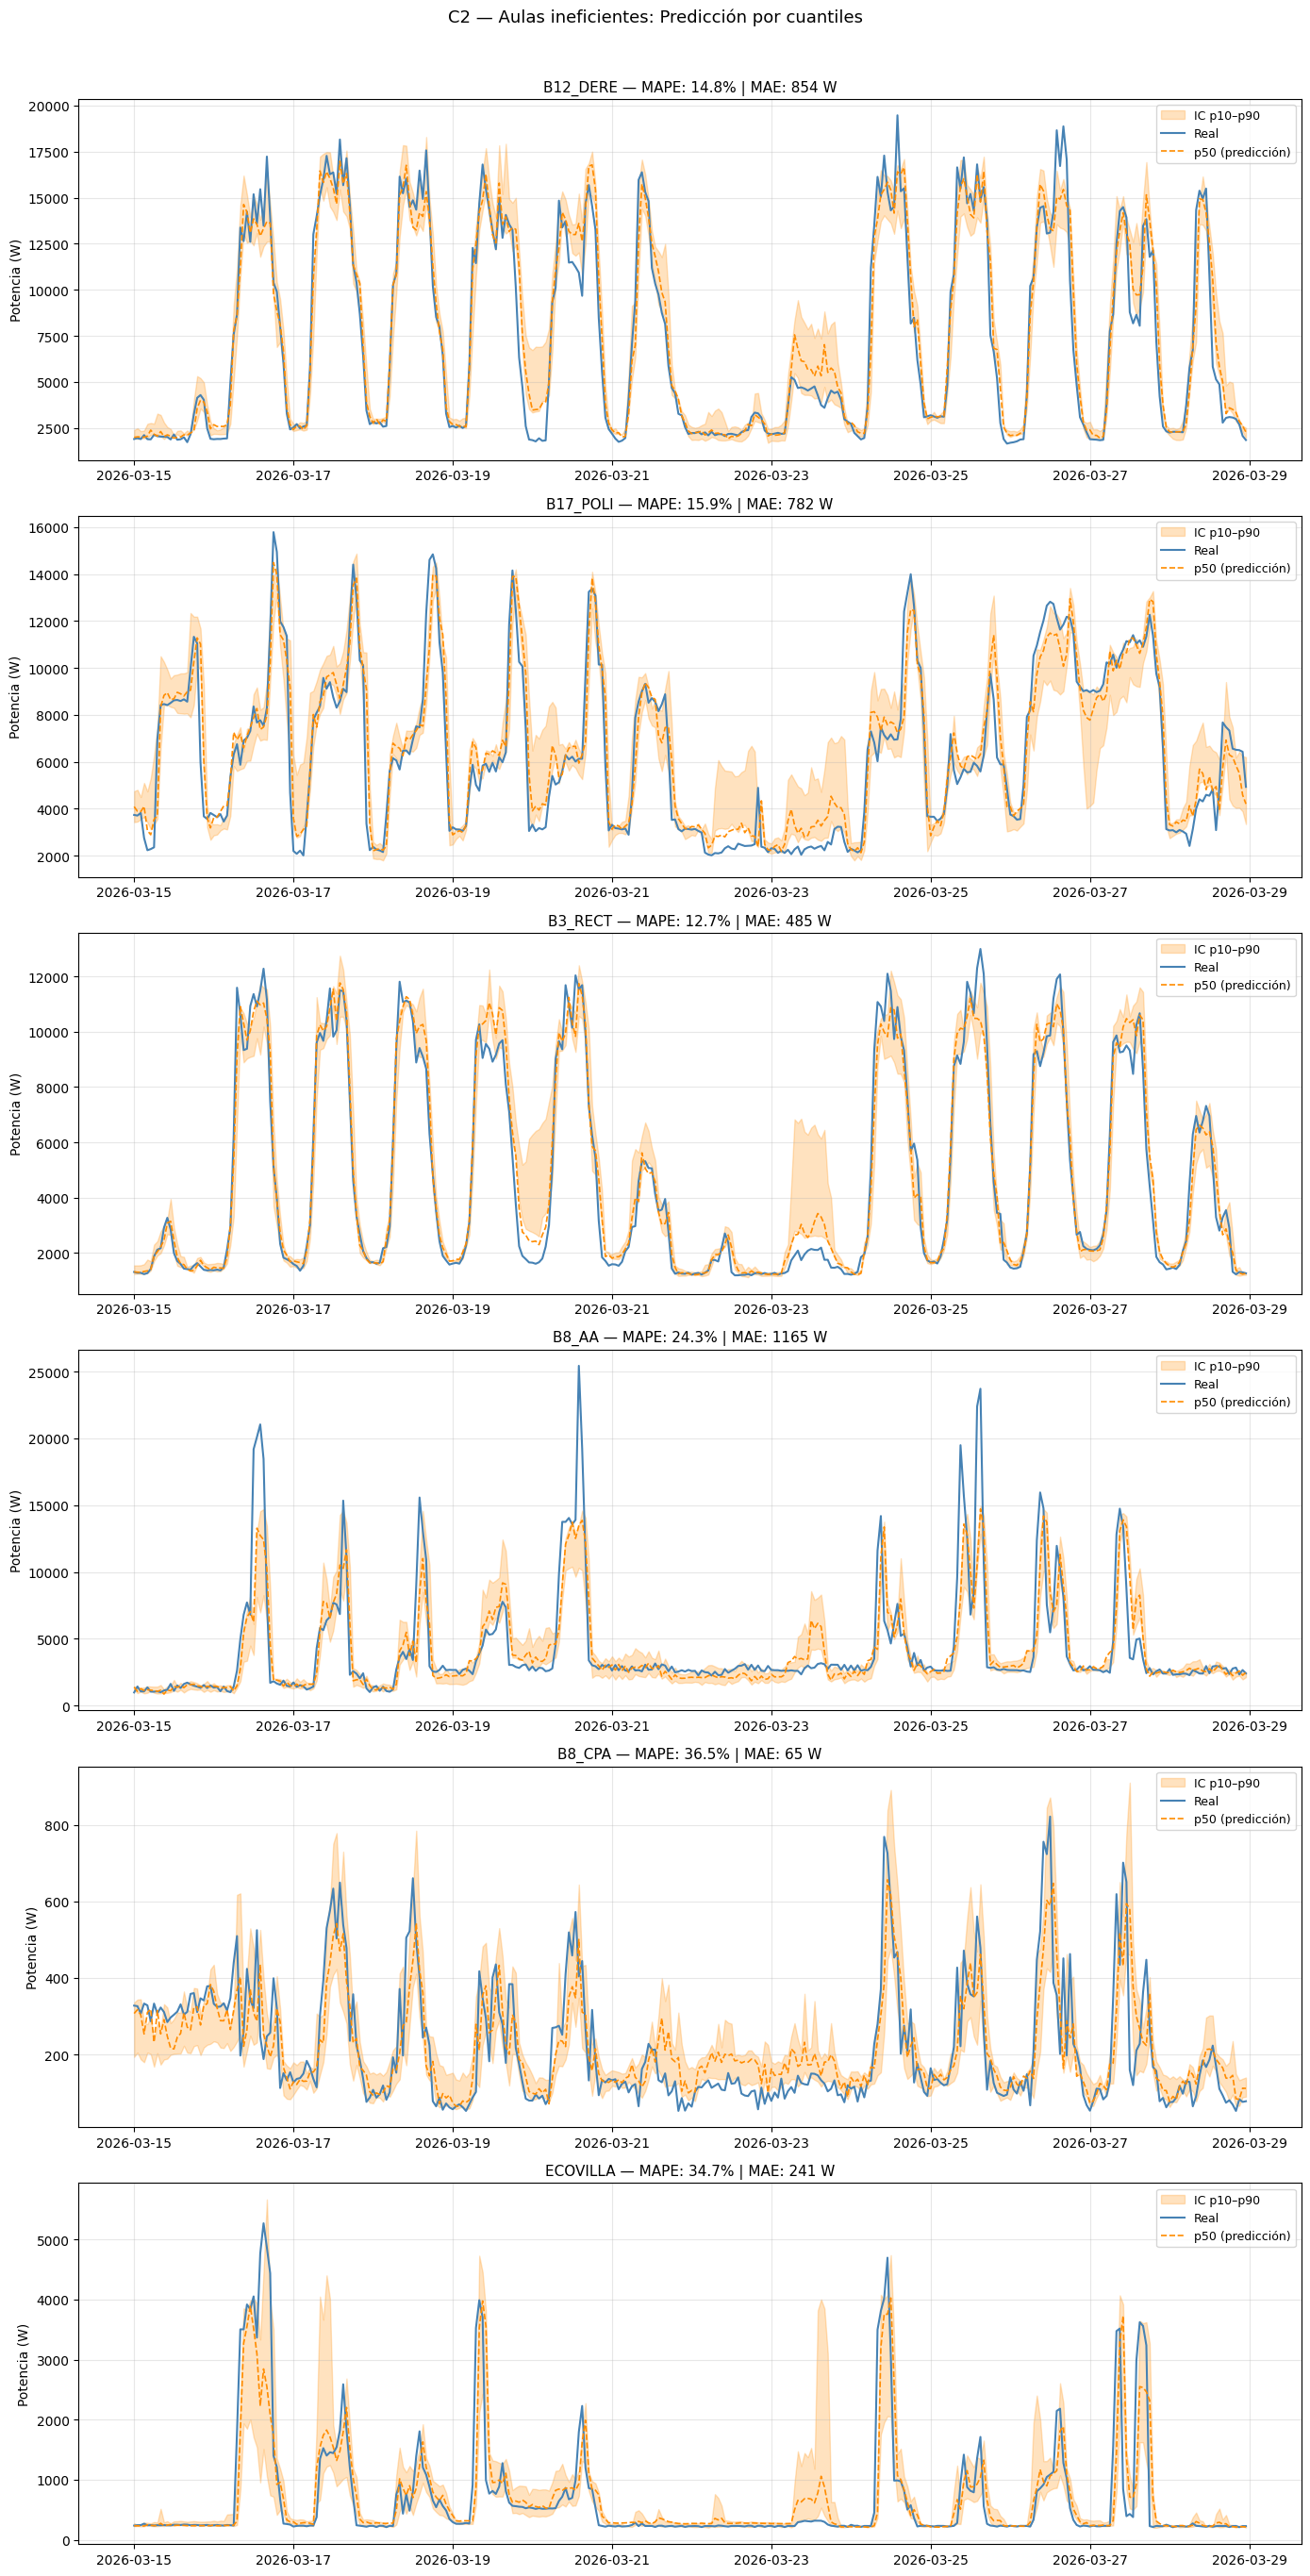

In [24]:
# Visualización con intervalos de confianza p10–p90
bloques_c2 = sorted(result_c2['entity_id'].unique())
n = len(bloques_c2)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n), sharex=False)

for ax, bloque in zip(axes, bloques_c2):
    mask = result_c2['entity_id'] == bloque
    sub  = result_c2[mask]
    mape = safe_mape(sub['y'], sub['y_pred_p50']) * 100
    mae  = mean_absolute_error(sub['y'], sub['y_pred_p50'])

    ax.fill_between(sub.index, sub['y_pred_p10'], sub['y_pred_p90'],
                    alpha=0.25, color='darkorange', label='IC p10–p90')
    ax.plot(sub.index, sub['y'], label='Real',    color='steelblue',  lw=1.5)
    ax.plot(sub.index, sub['y_pred_p50'], label='p50 (predicción)',
            color='darkorange', lw=1.2, ls='--')
    ax.set_title(
        f'{bloque.replace("SmartMeter_SM_","")} — MAPE: {mape:.1f}% | MAE: {mae:.0f} W',
        fontsize=11
    )
    ax.set_ylabel('Potencia (W)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('C2 — Aulas ineficientes: Predicción por cuantiles', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Resumen comparativo de todos los clústeres

In [25]:
# Compilar métricas totales por clúster
all_results = pd.concat([
    result_c3.assign(cluster='C3 – Operación constante'),
    result_c1.assign(cluster='C1 – Alto consumo eficiente'),
    result_c0.assign(cluster='C0 – Académico estándar'),
    result_c2[['y','entity_id','y_pred']].assign(cluster='C2 – Aulas ineficientes'),
])

summary_rows = []
for cluster_label in all_results['cluster'].unique():
    sub = all_results[all_results['cluster'] == cluster_label]
    n_bloques = sub['entity_id'].nunique()
    summary_rows.append({
        'Clúster': cluster_label,
        'Bloques': n_bloques,
        'MAE (W)':  mean_absolute_error(sub['y'], sub['y_pred']),
        'RMSE (W)': np.sqrt(mean_squared_error(sub['y'], sub['y_pred'])),
        'MAPE (%)': safe_mape(sub['y'], sub['y_pred']) * 100,
    })

df_summary = pd.DataFrame(summary_rows).set_index('Clúster').round(2)
print('Resumen por clúster:')
display(df_summary)

# Resumen por bloque individual (todos los clústeres)
print('\nResumen por bloque (todos los clústeres):')
all_block_rows = []
for cluster_label in all_results['cluster'].unique():
    sub = all_results[all_results['cluster'] == cluster_label]
    for bloque in sorted(sub['entity_id'].unique()):
        m = sub[sub['entity_id']==bloque]
        all_block_rows.append({
            'Clúster': cluster_label,
            'Bloque':  bloque.replace('SmartMeter_SM_',''),
            'MAE (W)':  round(mean_absolute_error(m['y'], m['y_pred']), 1),
            'RMSE (W)': round(np.sqrt(mean_squared_error(m['y'], m['y_pred'])), 1),
            'MAPE (%)': round(safe_mape(m['y'], m['y_pred'])*100, 1),
        })

df_block_summary = pd.DataFrame(all_block_rows).set_index(['Clúster','Bloque'])
display(df_block_summary)

Resumen por clúster:


,Bloques,MAE (W),RMSE (W),MAPE (%)
Clúster,,,,
C3 – Operación constante,1,1576.60,2672.66,5.11
C1 – Alto consumo eficiente,2,3451.64,4756.02,12.21
C0 – Académico estándar,6,2170.56,3540.48,13.77
C2 – Aulas ineficientes,6,598.72,1213.81,23.14



Resumen por bloque (todos los clústeres):


MAE (W)  RMSE (W)  MAPE (%)
Clúster                     Bloque                               
C3 – Operación constante    B7_CTIC    1576.6    2672.7       5.1
C1 – Alto consumo eficiente B18_PARQ   4071.1    5406.3      15.6
                            B9_SFA1    2832.2    4001.5       8.8
C0 – Académico estándar     B10_ARQ    2055.1    3392.5      24.5
                            B4_PRIM    2160.6    3501.5      11.8
                            B5_BACH    2747.3    4408.5      11.7
                            B7_TAC     1586.0    2364.3      13.3
                            B8_LABS    1354.1    1813.5       9.5
                            B9_SFA2    3120.2    4809.1      11.7
C2 – Aulas ineficientes     B12_DERE    853.8    1293.3      14.8
                            B17_POLI    782.4    1117.3      15.9
                            B3_RECT     484.7     709.4      12.7
                            B8_AA      1165.2    2261.7      24.3
                            B8_CPA       64.9      92.6      36.5
                            ECOVILLA    241.3     540.2      34.7

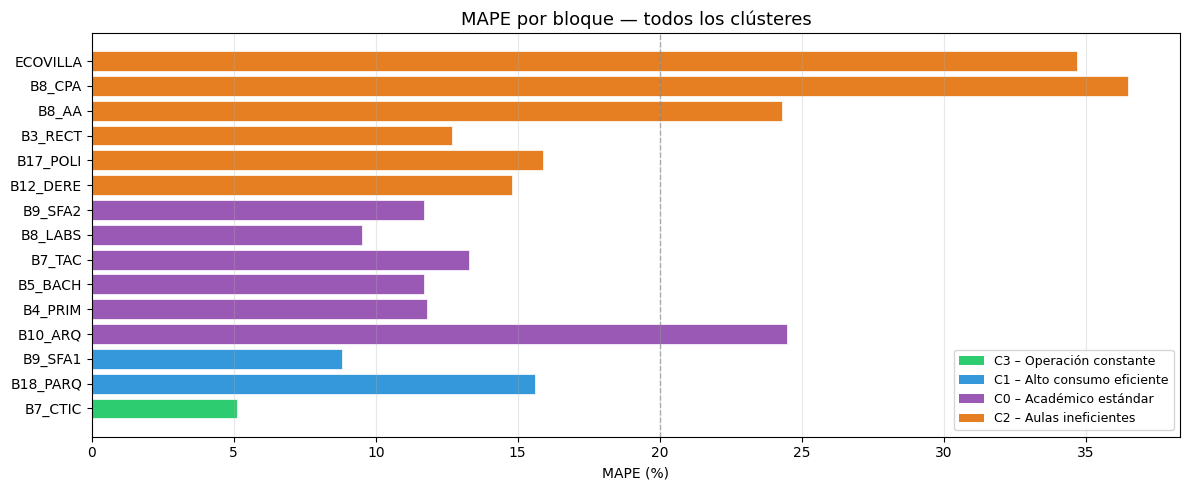

In [26]:
# Gráfico de MAPE por bloque
fig, ax = plt.subplots(figsize=(12, 5))

colors_map = {
    'C3 – Operación constante':     '#2ecc71',
    'C1 – Alto consumo eficiente':  '#3498db',
    'C0 – Académico estándar':      '#9b59b6',
    'C2 – Aulas ineficientes':      '#e67e22',
}

labels, values, bar_colors = [], [], []
for _, row in df_block_summary.reset_index().iterrows():
    labels.append(row['Bloque'])
    values.append(row['MAPE (%)'])
    bar_colors.append(colors_map.get(row['Clúster'], 'gray'))

bars = ax.barh(labels, values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE por bloque — todos los clústeres', fontsize=13)
ax.axvline(x=20, color='gray', ls='--', lw=1, alpha=0.6, label='20% referencia')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Leyenda de clústeres
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Persistencia de modelos

In [27]:
SAVE_DIR = '/content/drive/MyDrive/datos_limpios_prediccion/modelos_cluster/'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(modelo_c0, SAVE_DIR + 'modelo_c0_academico.joblib')
joblib.dump(modelo_c1, SAVE_DIR + 'modelo_c1_alto_consumo.joblib')
joblib.dump(modelos_c2, SAVE_DIR + 'modelos_c2_aulas_cuantil.joblib')  # dict con 3 modelos
joblib.dump(modelo_c3, SAVE_DIR + 'modelo_c3_constante.joblib')

# Guardar también los encoding de bloques por clúster
meta = {
    'cluster_map':    CLUSTER_MAP,
    'bloque_enc_c0':  c0_data['bloque_enc'],
    'bloque_enc_c1':  c1_data['bloque_enc'],
    'bloque_enc_c2':  c2_data['bloque_enc'],
    'bloque_enc_c3':  c3_data['bloque_enc'],
    'feature_cols':   c0_data['feature_cols'],  # Mismas features para todos
    'cutoff_date':    str(CUTOFF_DATE.date()),
}
joblib.dump(meta, SAVE_DIR + 'meta_cluster.joblib')

print('✅ Modelos y metadata guardados en:', SAVE_DIR)
print('   modelo_c0_academico.joblib')
print('   modelo_c1_alto_consumo.joblib')
print('   modelos_c2_aulas_cuantil.joblib  ← dict {0.1, 0.5, 0.9}')
print('   modelo_c3_constante.joblib')
print('   meta_cluster.joblib')

✅ Modelos y metadata guardados en: /content/drive/MyDrive/datos_limpios_prediccion/modelos_cluster/
   modelo_c0_academico.joblib
   modelo_c1_alto_consumo.joblib
   modelos_c2_aulas_cuantil.joblib  ← dict {0.1, 0.5, 0.9}
   modelo_c3_constante.joblib
   meta_cluster.joblib


## 11. Función de predicción futura

Para generar predicciones reales (post-apagón o nuevos datos) sin re-entrenar.
Carga los modelos guardados y construye los features para el horizonte deseado.

In [28]:
def predecir_bloque(entity_id: str, df_historico: pd.DataFrame,
                    horizon_h: int = 24) -> pd.DataFrame:
    """
    Genera predicción para un bloque dado usando el modelo de su clúster.

    Args:
        entity_id:     Nombre del bloque (ej: 'SmartMeter_SM_B10_ARQ')
        df_historico:  DataFrame con columnas ['time_index_colombia', 'activepower']
                       para el bloque. Debe tener al menos 24h de historia.
        horizon_h:     Horas a predecir hacia adelante (default: 24 = 1 día)

    Returns:
        DataFrame con columnas: timestamp, y_pred (y y_pred_p10/p90 para C2)
    """
    cluster_id = CLUSTER_MAP[entity_id]

    # Seleccionar modelo
    if cluster_id == 0:
        modelo, bloque_enc_map = modelo_c0, c0_data['bloque_enc']
    elif cluster_id == 1:
        modelo, bloque_enc_map = modelo_c1, c1_data['bloque_enc']
    elif cluster_id == 2:
        modelo, bloque_enc_map = modelos_c2[0.5], c2_data['bloque_enc']
    else:
        modelo, bloque_enc_map = modelo_c3, c3_data['bloque_enc']

    # Preparar historia
    sub = (
        df_historico[df_historico['entity_id'] == entity_id]
        .set_index('time_index_colombia')
        .sort_index()[['activepower']]
        .rename(columns={'activepower': 'y'})
        .asfreq('h')
    )

    # Construir timestamps futuros
    last_ts   = sub.index[-1]
    future_ts = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon_h, freq='h')

    # Predicción iterativa (necesario para lags)
    full = sub['y'].copy()
    preds = []

    for ts in future_ts:
        # Construir fila de features para este timestamp
        tmp = pd.DataFrame({'y': [np.nan]}, index=[ts])
        full_tmp = pd.concat([full, tmp])
        feat_row = build_features(full_tmp).iloc[[-1]]

        feat_row['bloque_enc'] = bloque_enc_map.get(entity_id, -1)
        feat_row = feat_row[c0_data['feature_cols']]  # Orden consistente

        pred = float(modelo.predict(feat_row)[0])
        pred = max(0, pred)
        preds.append(pred)
        full[ts] = pred  # Usar predicción como historia para el siguiente paso

    result = pd.DataFrame({'timestamp': future_ts, 'y_pred': preds})

    # Para C2: también incluir p10 y p90
    if cluster_id == 2:
        full_p10 = sub['y'].copy()
        full_p90 = sub['y'].copy()
        preds_p10, preds_p90 = [], []

        for i, ts in enumerate(future_ts):
            tmp = pd.DataFrame({'y': [np.nan]}, index=[ts])
            # p10
            feat_row_p10 = build_features(pd.concat([full_p10, tmp])).iloc[[-1]]
            feat_row_p10['bloque_enc'] = bloque_enc_map.get(entity_id, -1)
            feat_row_p10 = feat_row_p10[c0_data['feature_cols']]
            pred_p10 = max(0, float(modelos_c2[0.1].predict(feat_row_p10)[0]))
            preds_p10.append(pred_p10)
            full_p10[ts] = pred_p10
            # p90
            feat_row_p90 = build_features(pd.concat([full_p90, tmp])).iloc[[-1]]
            feat_row_p90['bloque_enc'] = bloque_enc_map.get(entity_id, -1)
            feat_row_p90 = feat_row_p90[c0_data['feature_cols']]
            pred_p90 = max(0, float(modelos_c2[0.9].predict(feat_row_p90)[0]))
            preds_p90.append(pred_p90)
            full_p90[ts] = pred_p90

        result['y_pred_p10'] = preds_p10
        result['y_pred_p90'] = preds_p90

    return result


# Ejemplo de uso
print('Función predecir_bloque() definida.')
print('Uso: predecir_bloque("SmartMeter_SM_B7_CTIC", df_raw, horizon_h=168)')

Función predecir_bloque() definida.
Uso: predecir_bloque("SmartMeter_SM_B7_CTIC", df_raw, horizon_h=168)


In [29]:
predecir_bloque("SmartMeter_SM_B7_CTIC", df_raw, horizon_h=168)

,timestamp,y_pred
0,2026-03-29 00:00:00,32853.226562
1,2026-03-29 01:00:00,33221.390625
2,2026-03-29 02:00:00,33268.949219
3,2026-03-29 03:00:00,33250.863281
4,2026-03-29 04:00:00,33325.070312
...,...,...
163,2026-04-04 19:00:00,35282.187500
164,2026-04-04 20:00:00,34907.718750
165,2026-04-04 21:00:00,34716.933594
166,2026-04-04 22:00:00,35292.449219
